In [12]:
import os
import csv
import math as m
chamber = ["right", "left"]
fiber_right_dof = []
fiber_left_dof = []
fiber_right_spring_info = []
fiber_left_spring_info = []

# Specify the path to your CSV file
for i in chamber:
    for j in range(2):
        if i == "right":
            fiber_right_dof.append([]) 
        else:
            fiber_left_dof.append([])
        file_path = os.getcwd()+"/fiber" + str(j+1) + i +"_info.csv"

        # Open the CSV file
        with open(file_path, 'r') as file:
            # Create a CSV reader object as a dictionary reader
            csv_reader = csv.DictReader(file)
            for row in csv_reader:
                if i == "right":
                    fiber_right_dof[-1].append(float(row['x (mm)'])) 
                    fiber_right_dof[-1].append(float(row['y (mm)']))
                    fiber_right_dof[-1].append(float(row['z (mm)']))

                else:
                    fiber_left_dof[-1].append(float(row['x (mm)'])) 
                    fiber_left_dof[-1].append(float(row['y (mm)']))
                    fiber_left_dof[-1].append(float(row['z (mm)']))

 

In [8]:
fiber_right_dof
print(len(fiber_right_dof))
print(len(fiber_right_dof[0]))

2
861


In [13]:
Ks = 1e3
Kd = 5
for i in range(len(fiber_right_dof)):
    fiber_right_spring_info.append([])
    fiber_left_spring_info.append([])
    for j in range(0,int(len(fiber_right_dof[i])/3)-2):
        fiber_right_spring_info[-1].append([j, j+1, Ks, Kd, m.sqrt((fiber_right_dof[i][3*j]-fiber_right_dof[i][3*(j+1)])**2+
                                                            (fiber_right_dof[i][3*j+1]-fiber_right_dof[i][3*(j+1)+1])**2+
                                                            (fiber_right_dof[i][3*j+2]-fiber_right_dof[i][3*(j+1)+2])**2)])
        
        fiber_left_spring_info[-1].append([j, j+1, Ks, Kd, m.sqrt((fiber_left_dof[i][3*j]-fiber_left_dof[i][3*(j+1)])**2+
                                                            (fiber_left_dof[i][3*j+1]-fiber_left_dof[i][3*(j+1)+1])**2+
                                                            (fiber_left_dof[i][3*j+2]-fiber_left_dof[i][3*(j+1)+2])**2)])

In [14]:
fiber_dof = [fiber_right_dof, fiber_left_dof]
spring_info = [fiber_right_spring_info, fiber_left_spring_info]

SystemExit: 0

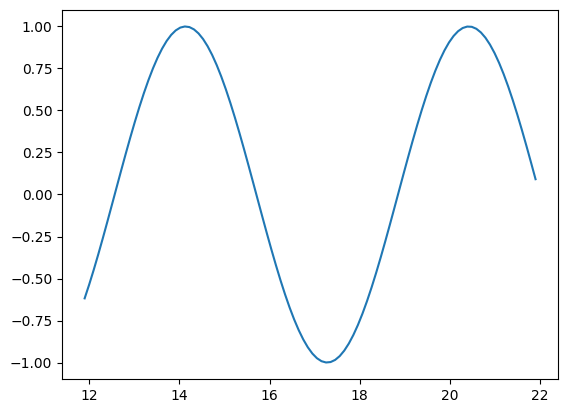

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas
from PyQt5.QtWidgets import QApplication, QMainWindow, QVBoxLayout, QWidget
from PyQt5.QtCore import Qt, QTimer

class RealTimePlot(QMainWindow):
    def __init__(self):
        super().__init__()

        self.central_widget = QWidget(self)
        self.setCentralWidget(self.central_widget)

        layout = QVBoxLayout(self.central_widget)

        self.figure, self.ax = plt.subplots()
        self.canvas = FigureCanvas(self.figure)
        layout.addWidget(self.canvas)

        self.x = np.linspace(0, 10, 100)
        self.y = np.sin(self.x)

        self.line, = self.ax.plot(self.x, self.y)

        # Set up a timer to update the plot every 100 milliseconds
        self.timer = QTimer(self)
        self.timer.timeout.connect(self.update_plot)
        self.timer.start(100)

    def update_plot(self):
        # Update the data
        self.x += 0.1
        self.y = np.sin(self.x)

        # Update the plot
        self.line.set_data(self.x, self.y)
        self.ax.relim()
        self.ax.autoscale_view()

        # Redraw the canvas
        self.canvas.draw()

if __name__ == '__main__':
    app = QApplication(sys.argv)
    window = RealTimePlot()
    window.show()
    sys.exit(app.exec_())


In [37]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.style.use('fivethirtyeight')
import pandas as pd
fieldnames = ["time","xx", "yy", "zz", "yz", "xz", "xy"]
count = 0
def animate(i, count):
    data = pd.read_csv('strain_data.csv')
    no_data = 100
    x = data['time']
    y1 = data['xx']
    y2 = data['yy']
    y3 = data['zz']
    y4 = data['yz']
    y5 = data['xz']
    y6 = data['xy']
    plt.set_xlim(x.min(), x.max())
    plt.cla()

    plt.plot(x[no_data*count:no_data*(count+1)], y1[no_data*count:no_data*(count+1)], label='Channel 1')
    plt.plot(x[no_data*count:no_data*(count+1)], y2[no_data*count:no_data*(count+1)], label='Channel 2')
    plt.plot(x[no_data*count:no_data*(count+1)], y3[no_data*count:no_data*(count+1)], label='Channel 3')
    plt.plot(x[no_data*count:no_data*(count+1)], y4[no_data*count:no_data*(count+1)], label='Channel 4')
    plt.plot(x[no_data*count:no_data*(count+1)], y5[no_data*count:no_data*(count+1)], label='Channel 5')
    plt.plot(x[no_data*count:no_data*(count+1)], y6[no_data*count:no_data*(count+1)], label='Channel 6')

    plt.legend(loc='upper left')
    plt.tight_layout()
    count += 1
    print(count)
    

ani = FuncAnimation(plt.gcf(), animate, frames=10, interval=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_31145/3993657560.py:42: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = FuncAnimation(plt.gcf(), animate, interval=1000)
/home/nhnhan/.pyenv/versions/3.10.13/envs/sofa/lib/python3.10/site-packages/matplotlib/animation.py:884: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

In [8]:
import csv
import random
import time

x_value = 0
total_1 = 1000
total_2 = 1000

fieldnames = ["x_value", "total_1", "total_2"]


with open('data.csv', 'w') as csv_file:
    csv_writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    csv_writer.writeheader()

while True:

    with open('data.csv', 'a') as csv_file:
        csv_writer = csv.DictWriter(csv_file, fieldnames=fieldnames)

        info = {
            "x_value": x_value,
            "total_1": total_1,
            "total_2": total_2
        }

        csv_writer.writerow(info)
        print(x_value, total_1, total_2)

        x_value += 1
        total_1 = total_1 + random.randint(-6, 8)
        total_2 = total_2 + random.randint(-5, 6)

    time.sleep(1)

0 1000 1000
1 1006 1002
2 1009 1005
3 1011 1003
4 1005 999
5 1006 999
6 1013 1000
7 1016 999
8 1023 995
9 1025 1001
10 1032 996
11 1032 991


KeyboardInterrupt: 

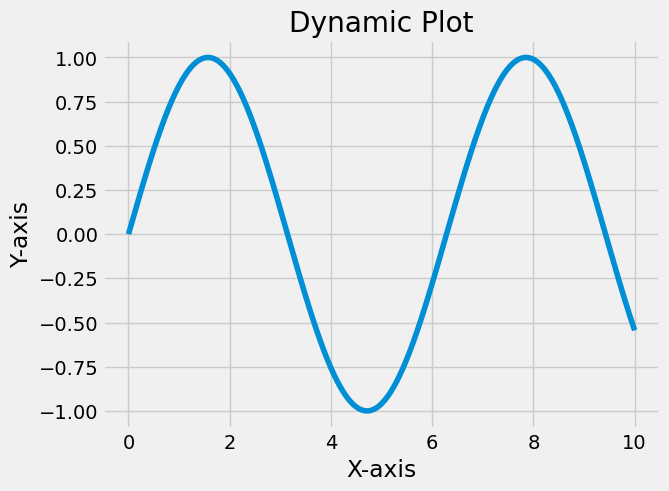

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

# Function to update the plot in each frame
def update(frame):
    y = np.sin(x + frame * 0.1)
    line.set_ydata(y)

    # Set x-axis limits to keep the scale constant
    ax.set_xlim(x.min(), x.max())

    return line,

# Sample data
x = np.linspace(0, 10000, 100)
y = np.sin(x)

# Create the figure and axis
fig, ax = plt.subplots()
line, = ax.plot(x, y)
ax.set_title('Dynamic Plot')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')

# Create the animation
animation = FuncAnimation(fig, update, frames=100, interval=100)

# Display the plot
plt.show()


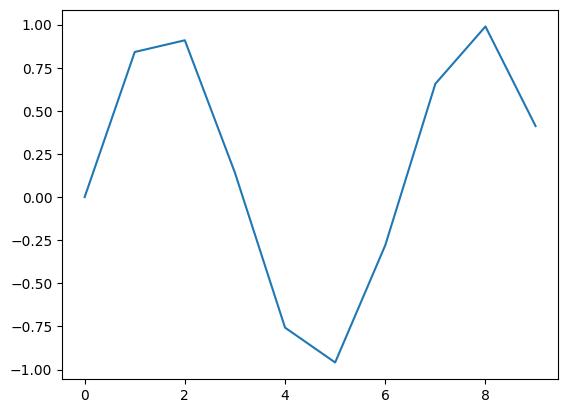

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output

# Khởi tạo đồ thị
fig, ax = plt.subplots()
x_values = []
y_values = []
line, = ax.plot(x_values, y_values)

# Hàm cập nhật đồ thị
def update_plot(new_data):
    x_values.append(new_data[0])
    y_values.append(new_data[1])
    line.set_xdata(x_values)
    line.set_ydata(y_values)
    ax.relim()
    ax.autoscale_view()
    display(fig)
    clear_output(wait=True)

# Mô phỏng việc nhận được dữ liệu mới và cập nhật đồ thị
for i in range(10):
    new_data_point = [i, np.sin(i)]  # Thay thế bằng dữ liệu thực tế của bạn
    update_plot(new_data_point)


0.0011591896889556373


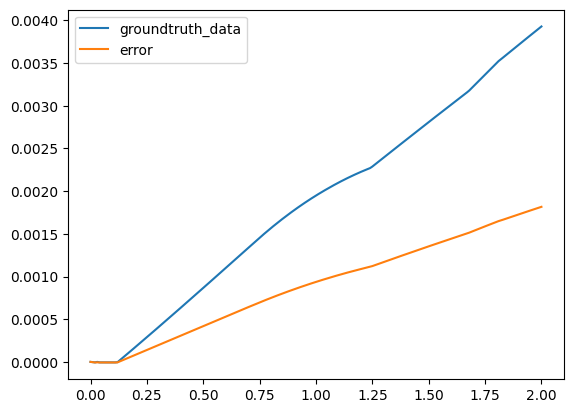

In [62]:
data = pd.read_csv("strain_groundtruth/strain_1785.csv")
x = data['Sim_step']
y = data['lamda_xz']
fig, ax = plt.subplots()
ax.plot(x,y,label="groundtruth_data")

data1 = pd.read_csv("strain_groundtruth/strain_1392.csv")
x1 = data1['Sim_step']
y1 = data1['lamda_xz']
ax.plot(x1,y1,label="error")
ax.legend(loc='upper left')

current_cost = np.sqrt(np.mean((y[1:] - y1[1:])**2))
print(current_cost)

In [30]:
import numpy as np
import math as m
from design_space import get_robot_class

check = get_robot_class('Leg')
check


SyntaxError: invalid syntax (1791511410.py, line 5)

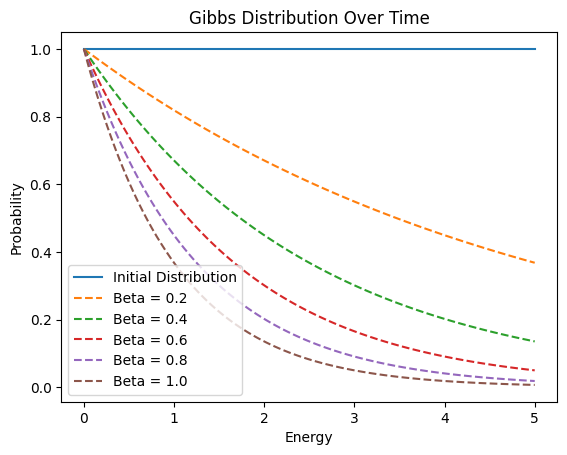

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate Gibbs distribution
def gibbs_distribution(energy, beta):
    return np.exp(-beta * energy)

# Function to update Gibbs distribution over time
def update_gibbs_distribution(beta, num_steps):
    energies = np.linspace(0, 5, 100)  # Energy levels from 0 to 10
    probabilities = gibbs_distribution(energies, beta)
    plt.plot(energies, probabilities, label='Initial Distribution')

    for _ in range(num_steps):
        beta += 0.2  # Increment beta over time
        new_probabilities = gibbs_distribution(energies, beta)
        plt.plot(energies, new_probabilities, linestyle='--', label=f'Beta = {beta:.1f}')

    plt.title('Gibbs Distribution Over Time')
    plt.xlabel('Energy')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()

# Initial parameters
initial_beta = 0  # Inverse temperature
num_update_steps = 5  # Number of update steps

# Update and plot Gibbs distribution over time
update_gibbs_distribution(initial_beta, num_update_steps)


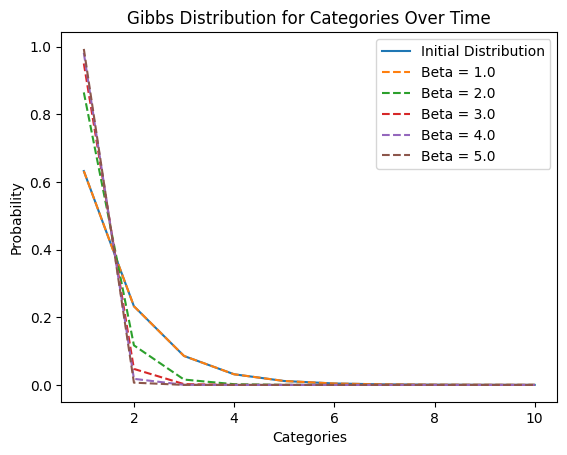

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate Gibbs distribution for categories
def gibbs_distribution_for_categories(categories, beta):
    # Calculate unnormalized probabilities using Gibbs distribution formula
    unnormalized_probabilities = np.exp(-beta * categories)
    
    # Normalize probabilities
    normalization_factor = np.sum(unnormalized_probabilities)
    probabilities = unnormalized_probabilities / normalization_factor
    
    return probabilities

# Function to update Gibbs distribution for categories over time
def update_gibbs_distribution_for_categories(categories, initial_beta, num_steps):
    plt.plot(categories, gibbs_distribution_for_categories(categories, initial_beta), label='Initial Distribution')

    for step in range(1, num_steps + 1):
        beta = initial_beta * step  # Increase beta over time
        plt.plot(categories, gibbs_distribution_for_categories(categories, beta), linestyle='--', label=f'Beta = {beta:.1f}')

    plt.title('Gibbs Distribution for Categories Over Time')
    plt.xlabel('Categories')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()

# Initial parameters
categories = np.arange(1, 11)  # Categories from 1 to 10
initial_beta = 1.0  # Initial inverse temperature
num_steps = 5  # Number of update steps

# Update and plot Gibbs distribution for categories over time
update_gibbs_distribution_for_categories(categories, initial_beta, num_steps)


[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


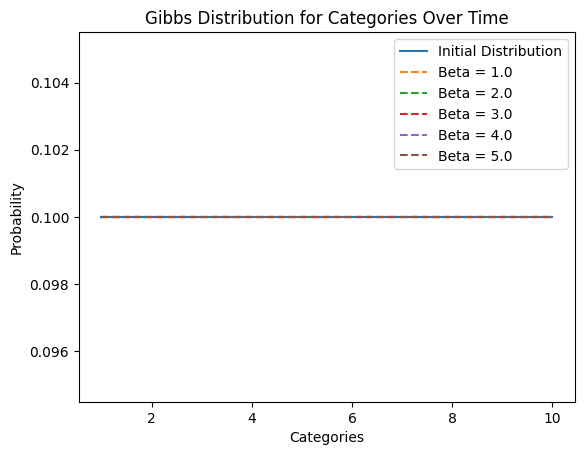

In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Custom categorical distribution using dl.CatDist
class CustomCategoricalDistribution:
    def __init__(self, logits):
        self.dist = torch.distributions.Categorical(logits=logits)

    def probabilities(self):
        return torch.softmax(self.dist.logits, dim=-1).numpy()  # Normalize logits to probabilities

# Function to calculate Gibbs distribution for categories using the custom distribution (CatDist)
def gibbs_distribution_for_categories(categories, logits, beta):
    custom_dist = CustomCategoricalDistribution(logits * beta)
    print(custom_dist.probabilities())
    return custom_dist.probabilities()

# Function to update Gibbs distribution for categories over time
def update_gibbs_distribution_for_categories(categories, initial_logits, initial_beta, num_steps):
    plt.plot(categories, gibbs_distribution_for_categories(categories, initial_logits, initial_beta), label='Initial Distribution')
    current_logits = initial_logits * 
    for step in range(1, num_steps + 1):
        updated_beta = initial_beta * step  # Update beta over time
        probabilities = gibbs_distribution_for_categories(categories, initial_logits, updated_beta)
        plt.plot(categories, probabilities, linestyle='--', label=f'Beta = {updated_beta:.1f}')

    plt.title('Gibbs Distribution for Categories Over Time')
    plt.xlabel('Categories')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()

# Example custom distribution function (replace this with your own distribution)
def custom_distribution(categories):
    # Example: Quadratic distribution
    return categories + 2

# Initial parameters
categories = np.arange(1, 11)  # Categories from 1 to 10
# initial_logits = torch.tensor(custom_distribution(categories), dtype=torch.float)  # Initial logits
initial_logits = torch.ones(10,dtype=torch.float)
initial_beta = 1.0  # Initial inverse temperature
num_steps = 5  # Number of update steps

# Update and plot Gibbs distribution for categories over time
update_gibbs_distribution_for_categories(categories, initial_logits, initial_beta, num_steps)


In [51]:
# initial_logits = torch.tensor(torch.ones(1,10))
# initial_logits
torch.ones(10)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])